# Comparative Analysis of Custom CNN and Transfer Learning Models with Explainable AI

Dataset: Kaggle `fatihkgg/ecommerce-product-images-18k`

This notebook implements the class activity requirements:

- Train and evaluate a custom CNN, MobileNetV2, and ResNet50.
- Report accuracy, precision, recall, F1-score, confusion matrices, training time, and trainable/total parameters.
- Visualize dataset samples, training curves, and model workflow.
- Generate Grad-CAM explanations for correct and incorrect predictions.
- Generate SHAP explanations for selected test images.
- Build a final comparison table for performance, cost, and explanation quality.

Recommended Kaggle setting: GPU accelerator.

## 1. Imports and Reproducibility

In [8]:
import os
import time
import random
import warnings
from pathlib import Path
from PIL import Image
from matplotlib.backends.backend_pdf import PdfPages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision policy:", tf.keras.mixed_precision.global_policy())
except Exception as exc:
    print("Mixed precision was not enabled:", exc)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

Mixed precision policy: <DTypePolicy "mixed_float16">
TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Runtime Configuration

The dataset path supplied in the prompt is kept first. Extra candidates make the notebook work when Kaggle mounts the dataset by slug.

In [9]:
USER_DATASET_PATH = Path("/kaggle/input/datasets/fatihkgg/ecommerce-product-images-18k")
FALLBACK_DATASET_PATHS = [
    Path("/kaggle/input/ecommerce-product-images-18k"),
    Path("/kaggle/input/ecommerce_product_images_18K"),
    Path("/kaggle/input"),
]

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VALID_SIZE = 0.15
TEST_SIZE = 0.15

EPOCHS_HEAD = 5
EPOCHS_FINE_TUNE = 3
RUN_FINE_TUNING = True

FINE_TUNE_LAST_N = {
    "MobileNetV2": 30,
    "ResNet50": 40,
}

# Keep None for the full project. Set an integer like 500 for a quicker demo run.
MAX_IMAGES_PER_CLASS = None

# SHAP is slower than Grad-CAM. Keep this small for a stable Kaggle run.
RUN_SHAP = True
SHAP_IMAGES_PER_MODEL = 1
SHAP_MAX_EVALS = 300

AUTOTUNE = tf.data.AUTOTUNE
OUTPUT_DIR = Path("/kaggle/working/nn_ecommerce_outputs") if Path("/kaggle/working").exists() else Path("nn_ecommerce_outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"
for directory in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SAVED_FIGURES = []
SAVED_TABLES = []


def safe_filename(name):
    cleaned = "".join(ch.lower() if ch.isalnum() else "_" for ch in str(name))
    cleaned = "_".join(part for part in cleaned.split("_") if part)
    return cleaned[:120] or "output"


def save_table(table, name, index=False):
    path = TABLE_DIR / f"{safe_filename(name)}.csv"
    if isinstance(table, pd.Series):
        table = table.to_frame()
    table.to_csv(path, index=index)
    SAVED_TABLES.append(path)
    print(f"Saved table: {path}")
    return path


def save_current_figure(name, fig=None):
    fig = fig or plt.gcf()
    stem = safe_filename(name)
    png_path = FIGURE_DIR / f"{stem}.png"
    pdf_path = FIGURE_DIR / f"{stem}.pdf"
    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    SAVED_FIGURES.append({"name": name, "png": png_path, "pdf": pdf_path})
    print(f"Saved figure: {png_path}")
    print(f"Saved figure PDF: {pdf_path}")
    return png_path, pdf_path


print("Outputs will be saved to:", OUTPUT_DIR)
print("Figures:", FIGURE_DIR)
print("Tables:", TABLE_DIR)
print("Models:", MODEL_DIR)

Outputs will be saved to: /kaggle/working/nn_ecommerce_outputs
Figures: /kaggle/working/nn_ecommerce_outputs/figures
Tables: /kaggle/working/nn_ecommerce_outputs/tables
Models: /kaggle/working/nn_ecommerce_outputs/models


## 3. Dataset Discovery and Label Extraction

This cell supports common Kaggle layouts:

- `class_name/image.jpg`
- `train/class_name/image.jpg`
- `class_name/images/image.jpg`

If your mounted folder is different, update `USER_DATASET_PATH` above.

In [10]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
GENERIC_IMAGE_DIRS = {
    "image", "images", "img", "imgs", "photo", "photos", "jpeg", "jpg", "png"
}


def list_images(root):
    root = Path(root)
    return sorted([p for p in root.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS])


def choose_dataset_root():
    candidates = [USER_DATASET_PATH] + FALLBACK_DATASET_PATHS
    for candidate in candidates:
        if candidate.exists() and list_images(candidate):
            return candidate

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        dataset_dirs = [p for p in kaggle_input.iterdir() if p.is_dir()]
        scored = [(len(list_images(p)), p) for p in dataset_dirs]
        scored = [(count, p) for count, p in scored if count > 0]
        if scored:
            scored.sort(reverse=True, key=lambda item: item[0])
            print("Auto-selected dataset folder:", scored[0][1])
            return scored[0][1]

    raise FileNotFoundError(
        "No images were found. Check that the Kaggle dataset is attached and update USER_DATASET_PATH if needed."
    )


def infer_label_from_path(path, root):
    path = Path(path)
    root = Path(root)
    parent = path.parent.name
    grandparent = path.parent.parent.name
    if parent.lower() in GENERIC_IMAGE_DIRS and path.parent.parent != root.parent:
        return grandparent
    return parent


DATA_ROOT = choose_dataset_root()
image_paths = list_images(DATA_ROOT)

df = pd.DataFrame({
    "path": [str(p) for p in image_paths],
    "label": [infer_label_from_path(p, DATA_ROOT) for p in image_paths],
})

class_counts = df["label"].value_counts()
df = df[df["label"].isin(class_counts[class_counts >= 3].index)].copy()

if MAX_IMAGES_PER_CLASS is not None:
    df = (
        df.groupby("label", group_keys=False)
        .apply(lambda part: part.sample(min(len(part), MAX_IMAGES_PER_CLASS), random_state=SEED))
        .reset_index(drop=True)
    )

class_names = sorted(df["label"].unique())
label_to_id = {label: idx for idx, label in enumerate(class_names)}
id_to_label = {idx: label for label, idx in label_to_id.items()}
df["label_id"] = df["label"].map(label_to_id).astype("int32")

if len(class_names) < 2:
    raise ValueError(
        "Fewer than two classes were detected. The notebook expects a folder-per-class image classification dataset."
    )

print("Dataset root:", DATA_ROOT)
print("Images:", len(df))
print("Classes:", len(class_names))
display(df["label"].value_counts().rename_axis("class").reset_index(name="images"))

Dataset root: /kaggle/input/datasets/fatihkgg/ecommerce-product-images-18k
Images: 18175
Classes: 9


,class,images
0,GROCERY,5166
1,HOME_KITCHEN_TOOLS,2228
2,ELECTRONICS,1757
3,PET_SUPPLIES,1637
4,SPORTS_OUTDOOR,1605
5,BEAUTY_HEALTH,1562
6,HOBBY_ARTS_STATIONERY,1417
7,BABY_PRODUCTS,1412
8,CLOTHING_ACCESSORIES_JEWELLERY,1391


## 4. Dataset Description and Samples

,Dataset name,Detected root,Number of images used,Number of classes,Original sample size,Model input size
0,E-commerce Product Images 18K,/kaggle/input/datasets/fatihkgg/ecommerce-prod...,18175,9,224 x 224,224 x 224


Saved table: /kaggle/working/nn_ecommerce_outputs/tables/dataset_description.csv
Saved table: /kaggle/working/nn_ecommerce_outputs/tables/class_distribution.csv
Saved figure: /kaggle/working/nn_ecommerce_outputs/figures/figure_1a_class_distribution.png
Saved figure PDF: /kaggle/working/nn_ecommerce_outputs/figures/figure_1a_class_distribution.pdf


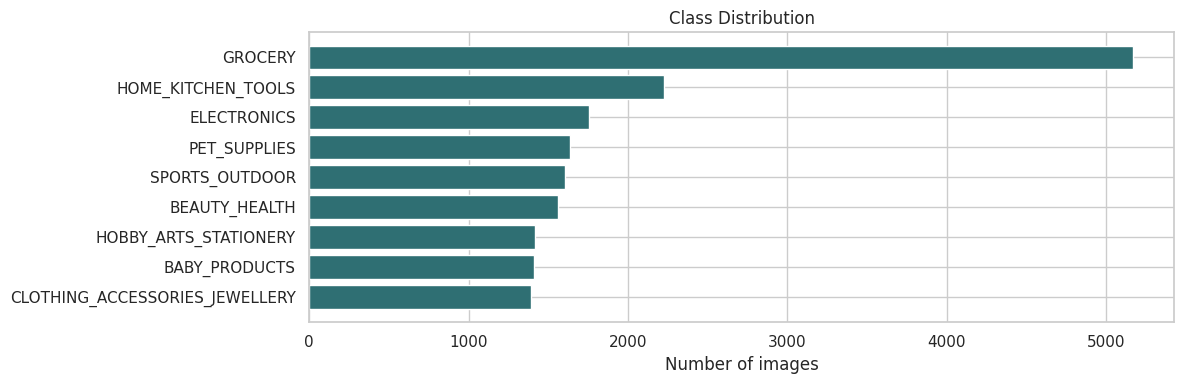

Saved figure: /kaggle/working/nn_ecommerce_outputs/figures/figure_1_dataset_samples.png
Saved figure PDF: /kaggle/working/nn_ecommerce_outputs/figures/figure_1_dataset_samples.pdf


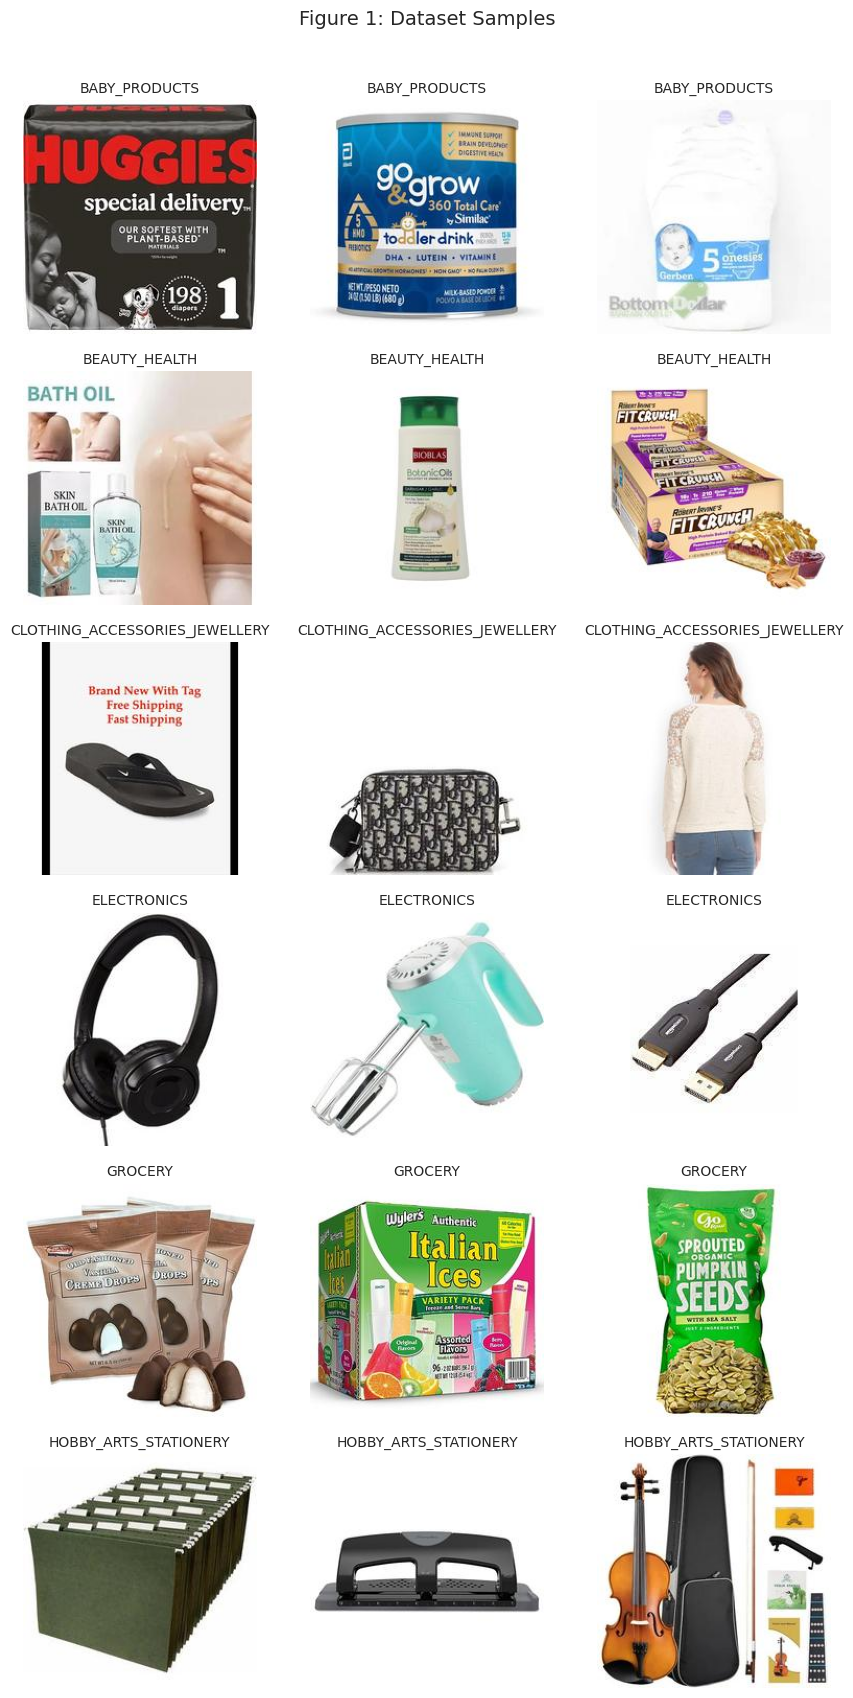

In [11]:
sample_path = Path(df.iloc[0]["path"])
with Image.open(sample_path) as img:
    original_size = img.size

dataset_description = pd.DataFrame([{
    "Dataset name": "E-commerce Product Images 18K",
    "Detected root": str(DATA_ROOT),
    "Number of images used": len(df),
    "Number of classes": len(class_names),
    "Original sample size": f"{original_size[0]} x {original_size[1]}",
    "Model input size": f"{IMG_SIZE[0]} x {IMG_SIZE[1]}",
}])
display(dataset_description)
save_table(dataset_description, "dataset_description")
class_distribution_df = df["label"].value_counts().rename_axis("class").reset_index(name="images")
save_table(class_distribution_df, "class_distribution")

fig = plt.figure(figsize=(12, max(4, min(10, len(class_names) * 0.35))))
count_data = df["label"].value_counts().sort_values(ascending=True)
if len(count_data) > 30:
    count_data = count_data.tail(30)
    plt.title("Class Distribution - Top 30 Classes by Image Count")
else:
    plt.title("Class Distribution")
plt.barh(count_data.index, count_data.values, color="#2f6f73")
plt.xlabel("Number of images")
plt.tight_layout()
save_current_figure("figure_1a_class_distribution", fig=fig)
plt.show()


def show_dataset_samples(dataframe, max_classes=6, samples_per_class=3):
    selected_classes = class_names[:max_classes]
    fig, axes = plt.subplots(
        len(selected_classes),
        samples_per_class,
        figsize=(samples_per_class * 3.0, len(selected_classes) * 2.8),
    )
    if len(selected_classes) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, label in enumerate(selected_classes):
        examples = dataframe[dataframe["label"] == label].sample(
            min(samples_per_class, (dataframe["label"] == label).sum()),
            random_state=SEED,
        )
        for col_idx in range(samples_per_class):
            ax = axes[row_idx, col_idx]
            ax.axis("off")
            if col_idx >= len(examples):
                continue
            image = keras.utils.load_img(examples.iloc[col_idx]["path"], target_size=IMG_SIZE)
            ax.imshow(image)
            ax.set_title(label, fontsize=10)

    plt.suptitle("Figure 1: Dataset Samples", y=1.01, fontsize=14)
    plt.tight_layout()
    save_current_figure("figure_1_dataset_samples", fig=fig)
    plt.show()


show_dataset_samples(df)

## 5. Train/Validation/Test Split and TensorFlow Pipelines

In [12]:
def safe_train_test_split(dataframe, test_size, stratify_col="label_id"):
    stratify = dataframe[stratify_col]
    try:
        return train_test_split(
            dataframe,
            test_size=test_size,
            random_state=SEED,
            stratify=stratify,
        )
    except ValueError as exc:
        print("Stratified split was not possible; using random split instead.")
        print("Reason:", exc)
        return train_test_split(
            dataframe,
            test_size=test_size,
            random_state=SEED,
            stratify=None,
        )


train_df, temp_df = safe_train_test_split(df, test_size=VALID_SIZE + TEST_SIZE)
relative_test_size = TEST_SIZE / (VALID_SIZE + TEST_SIZE)
val_df, test_df = safe_train_test_split(temp_df, test_size=relative_test_size)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "images": [len(train_df), len(val_df), len(test_df)],
})
display(split_summary)
save_table(split_summary, "train_validation_test_split")


def decode_and_resize(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.image.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE, method="bilinear")
    image = tf.cast(image, tf.float32)
    return image, label


def make_dataset(dataframe, shuffle=False):
    paths = dataframe["path"].astype(str).values
    labels = dataframe["label_id"].astype("int32").values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(min(len(dataframe), 4096), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

,split,images
0,train,12722
1,validation,2726
2,test,2727


Saved table: /kaggle/working/nn_ecommerce_outputs/tables/train_validation_test_split.csv


## 6. Model Design Workflow

Saved figure: /kaggle/working/nn_ecommerce_outputs/figures/figure_2_model_design_workflow.png
Saved figure PDF: /kaggle/working/nn_ecommerce_outputs/figures/figure_2_model_design_workflow.pdf


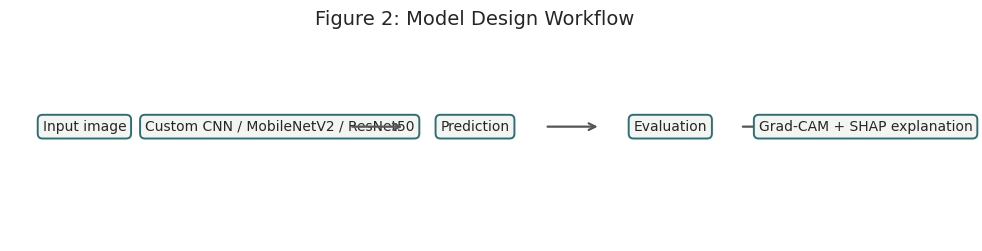

In [13]:
def plot_workflow():
    steps = [
        "Input image",
        "Custom CNN / MobileNetV2 / ResNet50",
        "Prediction",
        "Evaluation",
        "Grad-CAM + SHAP explanation",
    ]
    fig, ax = plt.subplots(figsize=(12, 2.7))
    ax.axis("off")
    x_positions = np.linspace(0.08, 0.92, len(steps))
    for idx, (x_pos, step) in enumerate(zip(x_positions, steps)):
        ax.text(
            x_pos,
            0.55,
            step,
            ha="center",
            va="center",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.35", fc="#f2f5f1", ec="#2f6f73", lw=1.4),
            transform=ax.transAxes,
        )
        if idx < len(steps) - 1:
            ax.annotate(
                "",
                xy=(x_positions[idx + 1] - 0.075, 0.55),
                xytext=(x_pos + 0.075, 0.55),
                arrowprops=dict(arrowstyle="->", lw=1.6, color="#555555"),
                xycoords=ax.transAxes,
            )
    plt.title("Figure 2: Model Design Workflow", fontsize=14)
    save_current_figure("figure_2_model_design_workflow", fig=fig)
    plt.show()


plot_workflow()

## 7. Model Builders

In [14]:
def make_augmentation(name):
    return keras.Sequential(
        [
            layers.RandomFlip("horizontal", seed=SEED),
            layers.RandomRotation(0.05, seed=SEED),
            layers.RandomZoom(0.10, seed=SEED),
            layers.RandomContrast(0.10, seed=SEED),
        ],
        name=name,
    )


def compile_model(model, learning_rate):
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_custom_cnn(num_classes):
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")
    x = make_augmentation("custom_augmentation")(inputs)
    x = layers.Rescaling(1.0 / 255.0, name="custom_rescaling")(x)

    x = layers.Conv2D(32, 3, padding="same", use_bias=False, name="custom_conv_1")(x)
    x = layers.BatchNormalization(name="custom_bn_1")(x)
    x = layers.Activation("relu", name="custom_relu_1")(x)
    x = layers.MaxPooling2D(name="custom_pool_1")(x)

    x = layers.Conv2D(64, 3, padding="same", use_bias=False, name="custom_conv_2")(x)
    x = layers.BatchNormalization(name="custom_bn_2")(x)
    x = layers.Activation("relu", name="custom_relu_2")(x)
    x = layers.MaxPooling2D(name="custom_pool_2")(x)

    x = layers.Conv2D(128, 3, padding="same", use_bias=False, name="custom_conv_3")(x)
    x = layers.BatchNormalization(name="custom_bn_3")(x)
    x = layers.Activation("relu", name="custom_relu_3")(x)
    x = layers.MaxPooling2D(name="custom_pool_3")(x)

    x = layers.Conv2D(256, 3, padding="same", use_bias=False, name="custom_last_conv")(x)
    x = layers.BatchNormalization(name="custom_last_bn")(x)
    x = layers.Activation("relu", name="custom_last_relu")(x)

    x = layers.GlobalAveragePooling2D(name="custom_gap")(x)
    x = layers.Dropout(0.35, seed=SEED, name="custom_dropout")(x)
    x = layers.Dense(256, activation="relu", name="custom_dense")(x)
    x = layers.Dropout(0.25, seed=SEED, name="custom_dense_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32", name="predictions")(x)

    model = keras.Model(inputs, outputs, name="Custom_CNN")
    compile_model(model, learning_rate=1e-3)
    return model, None


def build_transfer_model(model_name, application_fn, preprocess_fn, num_classes):
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name=f"{model_name}_image")
    x = make_augmentation(f"{model_name}_augmentation")(inputs)
    x = layers.Lambda(preprocess_fn, name=f"{model_name}_preprocess", output_shape=(*IMG_SIZE, 3))(x)

    try:
        base = application_fn(
            include_top=False,
            weights="imagenet",
            input_tensor=x,
            pooling=None,
        )
        weights_source = "imagenet"
    except Exception as exc:
        print(f"{model_name}: ImageNet weights could not be loaded. Falling back to random weights.")
        print("Reason:", exc)
        base = application_fn(
            include_top=False,
            weights=None,
            input_tensor=x,
            pooling=None,
        )
        weights_source = "random"

    base.trainable = False
    x = base.output
    x = layers.GlobalAveragePooling2D(name=f"{model_name}_gap")(x)
    x = layers.Dropout(0.35, seed=SEED, name=f"{model_name}_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32", name=f"{model_name}_predictions")(x)
    model = keras.Model(inputs, outputs, name=model_name)
    model.weights_source = weights_source
    compile_model(model, learning_rate=3e-4)
    return model, base


def find_last_4d_layer_name(model):
    for layer in reversed(model.layers):
        try:
            output_shape = layer.output.shape
            if len(output_shape) == 4:
                return layer.name
        except Exception:
            continue
    raise ValueError(f"No 4D convolutional feature layer found for {model.name}.")


custom_model, custom_base = build_custom_cnn(len(class_names))
mobilenet_model, mobilenet_base = build_transfer_model(
    "MobileNetV2",
    keras.applications.MobileNetV2,
    keras.applications.mobilenet_v2.preprocess_input,
    len(class_names),
)
resnet_model, resnet_base = build_transfer_model(
    "ResNet50",
    keras.applications.ResNet50,
    keras.applications.resnet50.preprocess_input,
    len(class_names),
)

models = {
    "Custom CNN": custom_model,
    "MobileNetV2": mobilenet_model,
    "ResNet50": resnet_model,
}
base_models = {
    "Custom CNN": custom_base,
    "MobileNetV2": mobilenet_base,
    "ResNet50": resnet_base,
}
last_conv_layers = {name: find_last_4d_layer_name(model) for name, model in models.items()}

architecture_rows = []
for name, model in models.items():
    trainable_params = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
    architecture_rows.append({
        "Model": name,
        "Total parameters": model.count_params(),
        "Trainable parameters before fine-tuning": trainable_params,
        "Grad-CAM feature layer": last_conv_layers[name],
        "Weights": getattr(model, "weights_source", "trained from scratch"),
    })

architecture_df = pd.DataFrame(architecture_rows)
display(architecture_df)
save_table(architecture_df, "model_architecture_table")

,Model,Total parameters,Trainable parameters before fine-tuning,Grad-CAM feature layer,Weights
0,Custom CNN,457961,457001,custom_last_relu,trained from scratch
1,MobileNetV2,2269513,11529,out_relu,imagenet
2,ResNet50,23606153,18441,conv5_block3_out,imagenet


Saved table: /kaggle/working/nn_ecommerce_outputs/tables/model_architecture_table.csv


PosixPath('/kaggle/working/nn_ecommerce_outputs/tables/model_architecture_table.csv')

## 8. Train the Three Models

In [15]:
def make_callbacks(model_name):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=1,
            min_lr=1e-6,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(MODEL_DIR / f"{model_name.replace(' ', '_')}.keras"),
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
    ]


def unfreeze_top_layers(base_model, last_n_layers):
    if base_model is None:
        return
    base_model.trainable = True
    for layer in base_model.layers[:-last_n_layers]:
        layer.trainable = False
    for layer in base_model.layers[-last_n_layers:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False


def merge_histories(history_objects):
    merged = {}
    for history in history_objects:
        for key, values in history.history.items():
            merged.setdefault(key, []).extend(values)
    return merged


histories = {}
training_rows = []

for model_name, model in models.items():
    print(f"\nTraining {model_name}")
    start_time = time.perf_counter()

    history_objects = []
    head_history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_HEAD,
        callbacks=make_callbacks(model_name + "_head"),
        verbose=1,
    )
    history_objects.append(head_history)

    base_model = base_models[model_name]
    if RUN_FINE_TUNING and base_model is not None and EPOCHS_FINE_TUNE > 0:
        print(f"Fine-tuning {model_name}")
        unfreeze_top_layers(base_model, FINE_TUNE_LAST_N[model_name])
        compile_model(model, learning_rate=1e-5)
        fine_history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS_FINE_TUNE,
            callbacks=make_callbacks(model_name + "_fine"),
            verbose=1,
        )
        history_objects.append(fine_history)

    elapsed = time.perf_counter() - start_time
    histories[model_name] = merge_histories(history_objects)

    trainable_params = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
    training_rows.append({
        "Model": model_name,
        "Training time (sec)": elapsed,
        "Training time (min)": elapsed / 60,
        "Total parameters": model.count_params(),
        "Trainable parameters after training": trainable_params,
    })

training_time_df = pd.DataFrame(training_rows)
display(training_time_df)
save_table(training_time_df, "training_time_and_parameters")


Training Custom CNN
Epoch 1/5


I0000 00:00:1780744221.096809     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


398/398 ━━━━━━━━━━━━━━━━━━━━ 64s 122ms/step - accuracy: 0.3603 - loss: 1.8440 - val_accuracy: 0.1104 - val_loss: 3.4748 - learning_rate: 0.0010
Epoch 2/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.4022 - loss: 1.7248 - val_accuracy: 0.2847 - val_loss: 2.1230 - learning_rate: 0.0010
Epoch 3/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.4179 - loss: 1.6756
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
398/398 ━━━━━━━━━━━━━━━━━━━━ 44s 109ms/step - accuracy: 0.4163 - loss: 1.6772 - val_accuracy: 0.3456 - val_loss: 2.9989 - learning_rate: 0.0010
Epoch 4/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.4388 - loss: 1.6025 - val_accuracy: 0.4050 - val_loss: 1.7958 - learning_rate: 3.0000e-04
Epoch 5/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.4506 - loss: 1.5650
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
398/398 ━━━━━━━━━━━━━━━━━━━━ 43s 108ms/step - accuracy: 0.4540 - loss: 1.5

,Model,Training time (sec),Training time (min),Total parameters,Trainable parameters after training
0,Custom CNN,237.230222,3.953837,457961,457001
1,MobileNetV2,243.798352,4.063306,2269513,1522249
2,ResNet50,398.788885,6.646481,23606153,15825161


Saved table: /kaggle/working/nn_ecommerce_outputs/tables/training_time_and_parameters.csv


PosixPath('/kaggle/working/nn_ecommerce_outputs/tables/training_time_and_parameters.csv')

## 9. Accuracy and Loss Curves

Saved figure: /kaggle/working/nn_ecommerce_outputs/figures/figure_3_accuracy_and_loss_curves.png
Saved figure PDF: /kaggle/working/nn_ecommerce_outputs/figures/figure_3_accuracy_and_loss_curves.pdf


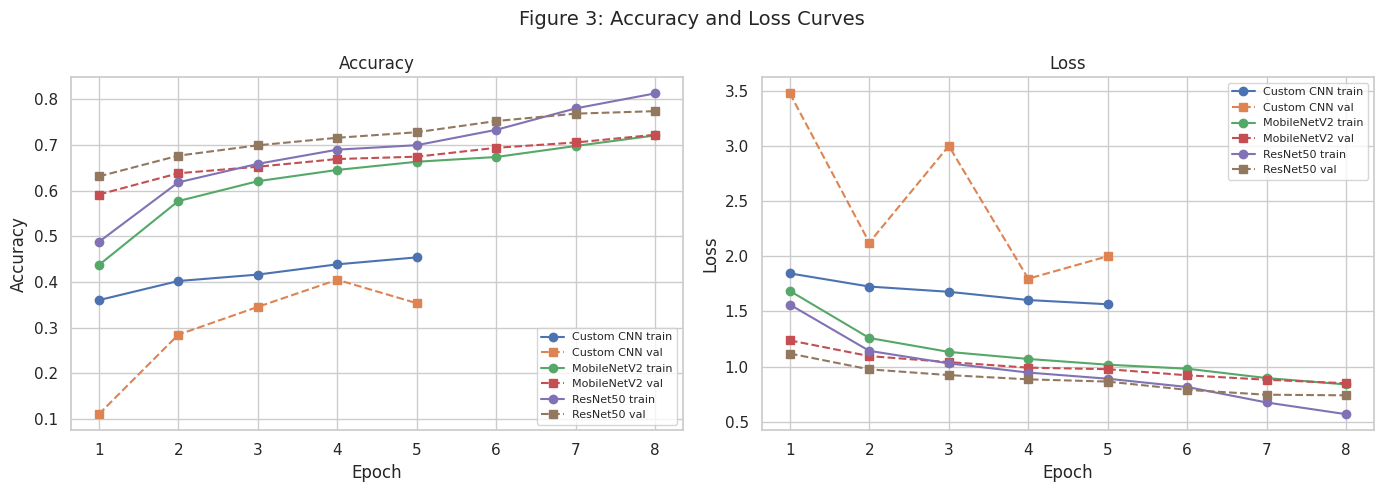

In [16]:
def plot_training_curves(histories):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for model_name, history in histories.items():
        epochs = range(1, len(history.get("accuracy", [])) + 1)
        axes[0].plot(epochs, history.get("accuracy", []), marker="o", label=f"{model_name} train")
        axes[0].plot(epochs, history.get("val_accuracy", []), marker="s", linestyle="--", label=f"{model_name} val")
        axes[1].plot(epochs, history.get("loss", []), marker="o", label=f"{model_name} train")
        axes[1].plot(epochs, history.get("val_loss", []), marker="s", linestyle="--", label=f"{model_name} val")

    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(fontsize=8)

    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend(fontsize=8)

    plt.suptitle("Figure 3: Accuracy and Loss Curves", fontsize=14)
    plt.tight_layout()
    save_current_figure("figure_3_accuracy_and_loss_curves", fig=fig)
    plt.show()


plot_training_curves(histories)

## 10. Model Evaluation

In [17]:
evaluation_rows = []
prediction_frames = {}
y_true = test_df["label_id"].to_numpy()

for model_name, model in models.items():
    print(f"Predicting with {model_name}")
    y_prob = model.predict(test_ds, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    accuracy = accuracy_score(y_true, y_pred)

    evaluation_rows.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
    })

    pred_df = test_df[["path", "label", "label_id"]].copy()
    pred_df["pred_id"] = y_pred
    pred_df["pred_label"] = [id_to_label[idx] for idx in y_pred]
    pred_df["confidence"] = y_prob.max(axis=1)
    pred_df["correct"] = pred_df["label_id"] == pred_df["pred_id"]
    prediction_frames[model_name] = pred_df
    save_table(pred_df, f"{model_name}_test_predictions")

metrics_df = pd.DataFrame(evaluation_rows)
metrics_df = metrics_df.merge(training_time_df, on="Model", how="left")
save_table(metrics_df, "model_metrics")
display(metrics_df)

best_model_name = metrics_df.sort_values("F1-score", ascending=False).iloc[0]["Model"]
print("Best model by weighted F1-score:", best_model_name)
print("\nClassification report for best model:")
print(classification_report(
    y_true,
    prediction_frames[best_model_name]["pred_id"],
    target_names=class_names,
    zero_division=0,
))

Predicting with Custom CNN
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step
Saved table: /kaggle/working/nn_ecommerce_outputs/tables/custom_cnn_test_predictions.csv
Predicting with MobileNetV2
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step
Saved table: /kaggle/working/nn_ecommerce_outputs/tables/mobilenetv2_test_predictions.csv
Predicting with ResNet50
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step
Saved table: /kaggle/working/nn_ecommerce_outputs/tables/resnet50_test_predictions.csv
Saved table: /kaggle/working/nn_ecommerce_outputs/tables/model_metrics.csv


,Model,Accuracy,Precision,Recall,F1-score,Training time (sec),Training time (min),Total parameters,Trainable parameters after training
0,Custom CNN,0.404107,0.393626,0.404107,0.336211,237.230222,3.953837,457961,457001
1,MobileNetV2,0.717638,0.711367,0.717638,0.710696,243.798352,4.063306,2269513,1522249
2,ResNet50,0.771177,0.775866,0.771177,0.770033,398.788885,6.646481,23606153,15825161


Best model by weighted F1-score: ResNet50

Classification report for best model:
                                precision    recall  f1-score   support

                 BABY_PRODUCTS       0.85      0.84      0.84       212
                 BEAUTY_HEALTH       0.78      0.53      0.63       235
CLOTHING_ACCESSORIES_JEWELLERY       0.84      0.88      0.86       208
                   ELECTRONICS       0.83      0.76      0.79       264
                       GROCERY       0.86      0.92      0.89       775
         HOBBY_ARTS_STATIONERY       0.71      0.67      0.69       212
            HOME_KITCHEN_TOOLS       0.53      0.64      0.58       334
                  PET_SUPPLIES       0.80      0.75      0.77       246
                SPORTS_OUTDOOR       0.70      0.66      0.68       241

                      accuracy                           0.77      2727
                     macro avg       0.77      0.74      0.75      2727
                  weighted avg       0.78      0.77  

## 11. Confusion Matrix Comparison

Figure 4: Confusion Matrix Comparison
Saved figure: /kaggle/working/nn_ecommerce_outputs/figures/figure_4_confusion_matrix_custom_cnn_normalized.png
Saved figure PDF: /kaggle/working/nn_ecommerce_outputs/figures/figure_4_confusion_matrix_custom_cnn_normalized.pdf


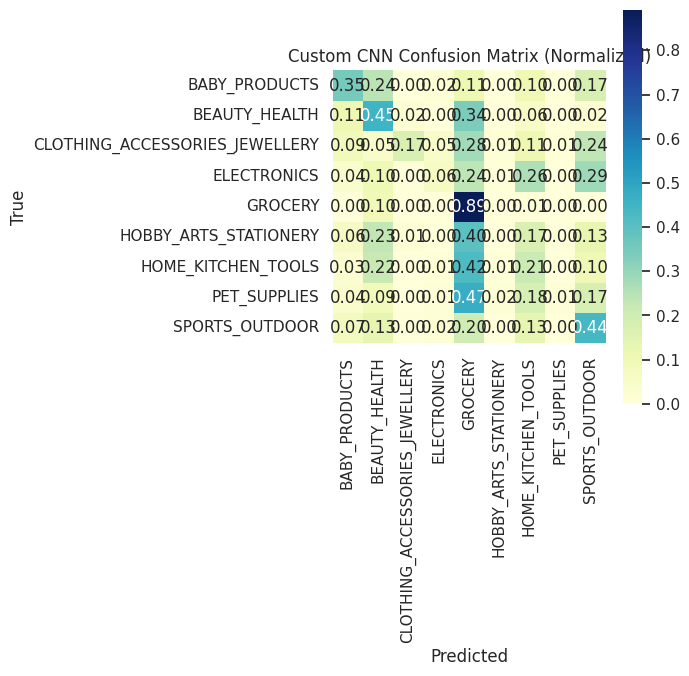

Saved figure: /kaggle/working/nn_ecommerce_outputs/figures/figure_4_confusion_matrix_mobilenetv2_normalized.png
Saved figure PDF: /kaggle/working/nn_ecommerce_outputs/figures/figure_4_confusion_matrix_mobilenetv2_normalized.pdf


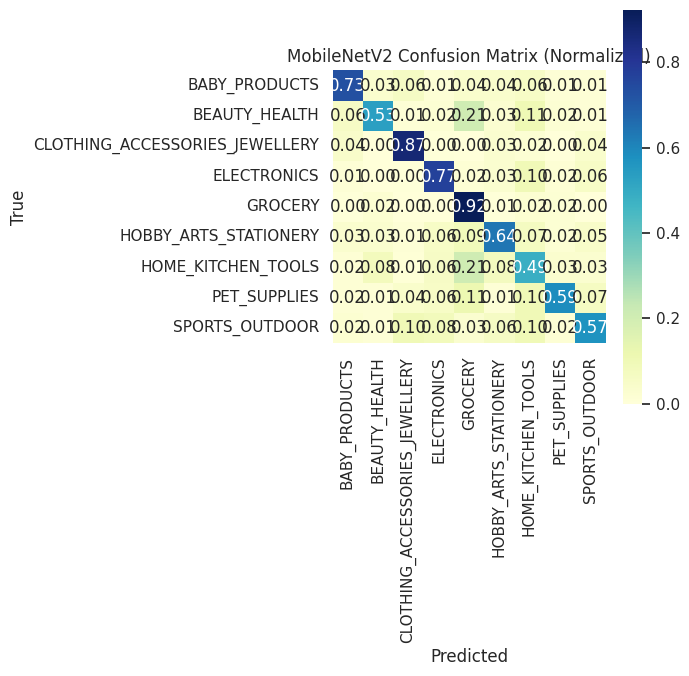

Saved figure: /kaggle/working/nn_ecommerce_outputs/figures/figure_4_confusion_matrix_resnet50_normalized.png
Saved figure PDF: /kaggle/working/nn_ecommerce_outputs/figures/figure_4_confusion_matrix_resnet50_normalized.pdf


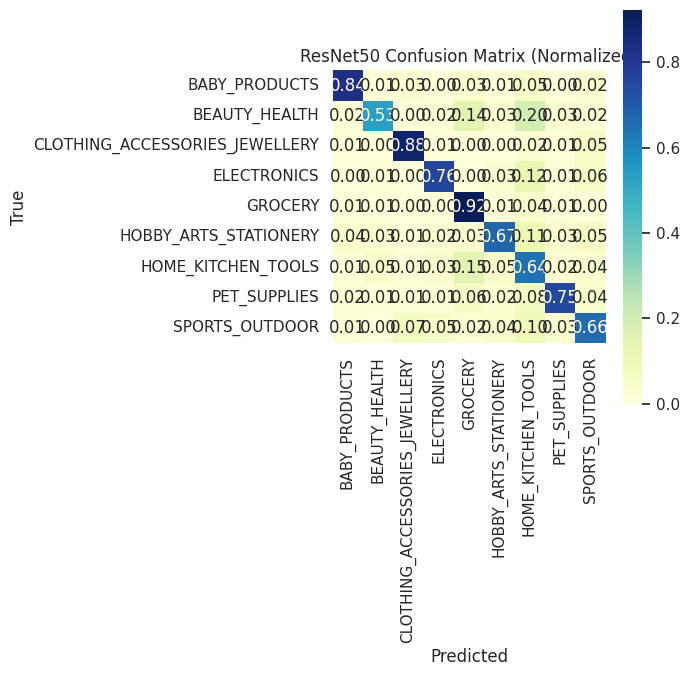

In [18]:
def plot_confusion_matrix(model_name, normalize=True):
    pred_df = prediction_frames[model_name]
    cm = confusion_matrix(y_true, pred_df["pred_id"], labels=list(range(len(class_names))))
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_to_plot = cm / row_sums
        fmt = ".2f"
        title_suffix = "Normalized"
    else:
        cm_to_plot = cm
        fmt = "d"
        title_suffix = "Counts"

    show_labels = class_names if len(class_names) <= 25 else False
    fig_size = max(7, min(16, len(class_names) * 0.55))
    plt.figure(figsize=(fig_size, fig_size))
    sns.heatmap(
        cm_to_plot,
        annot=len(class_names) <= 12,
        fmt=fmt,
        cmap="YlGnBu",
        xticklabels=show_labels,
        yticklabels=show_labels,
        cbar=True,
        square=True,
    )
    plt.title(f"{model_name} Confusion Matrix ({title_suffix})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    save_current_figure(f"figure_4_confusion_matrix_{model_name}_{title_suffix}", fig=plt.gcf())
    plt.show()


print("Figure 4: Confusion Matrix Comparison")
for model_name in models:
    plot_confusion_matrix(model_name, normalize=True)

## 12. Grad-CAM Helpers

In [19]:
def load_image_array(path):
    image = keras.utils.load_img(path, target_size=IMG_SIZE)
    return keras.utils.img_to_array(image).astype("float32")


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    img_batch = np.expand_dims(img_array, axis=0)
    grad_model = keras.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output],
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_batch, training=False)
        if pred_index is None:
            pred_index = int(tf.argmax(predictions[0]))
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    max_value = tf.reduce_max(heatmap)
    heatmap = heatmap / (max_value + tf.keras.backend.epsilon())
    return heatmap.numpy()


def overlay_heatmap(img_array, heatmap, alpha=0.40):
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    cmap = plt.get_cmap("jet")
    colors = cmap(np.arange(256))[:, :3]
    heatmap_rgb = colors[np.uint8(255 * heatmap_resized)]
    image = np.clip(img_array / 255.0, 0, 1)
    overlay = np.clip((1 - alpha) * image + alpha * heatmap_rgb, 0, 1)
    return overlay


def build_comparison_dataframe():
    comparison = test_df[["path", "label", "label_id"]].copy().reset_index(drop=True)
    for model_name, pred_df in prediction_frames.items():
        comparison[f"{model_name}_pred_id"] = pred_df["pred_id"].to_numpy()
        comparison[f"{model_name}_pred_label"] = pred_df["pred_label"].to_numpy()
        comparison[f"{model_name}_correct"] = pred_df["correct"].to_numpy()
    return comparison


comparison_df = build_comparison_dataframe()
display(comparison_df.head())

,path,label,label_id,Custom CNN_pred_id,Custom CNN_pred_label,Custom CNN_correct,MobileNetV2_pred_id,MobileNetV2_pred_label,MobileNetV2_correct,ResNet50_pred_id,ResNet50_pred_label,ResNet50_correct
0,/kaggle/input/datasets/fatihkgg/ecommerce-prod...,BABY_PRODUCTS,0,0,BABY_PRODUCTS,True,0,BABY_PRODUCTS,True,0,BABY_PRODUCTS,True
1,/kaggle/input/datasets/fatihkgg/ecommerce-prod...,SPORTS_OUTDOOR,8,8,SPORTS_OUTDOOR,True,8,SPORTS_OUTDOOR,True,8,SPORTS_OUTDOOR,True
2,/kaggle/input/datasets/fatihkgg/ecommerce-prod...,ELECTRONICS,3,4,GROCERY,False,3,ELECTRONICS,True,3,ELECTRONICS,True
3,/kaggle/input/datasets/fatihkgg/ecommerce-prod...,HOBBY_ARTS_STATIONERY,5,6,HOME_KITCHEN_TOOLS,False,1,BEAUTY_HEALTH,False,6,HOME_KITCHEN_TOOLS,False
4,/kaggle/input/datasets/fatihkgg/ecommerce-prod...,GROCERY,4,4,GROCERY,True,4,GROCERY,True,4,GROCERY,True


## 13. Grad-CAM for Correct Predictions

Saved figure: /kaggle/working/nn_ecommerce_outputs/figures/figure_5_grad_cam_correct_prediction_example.png
Saved figure PDF: /kaggle/working/nn_ecommerce_outputs/figures/figure_5_grad_cam_correct_prediction_example.pdf


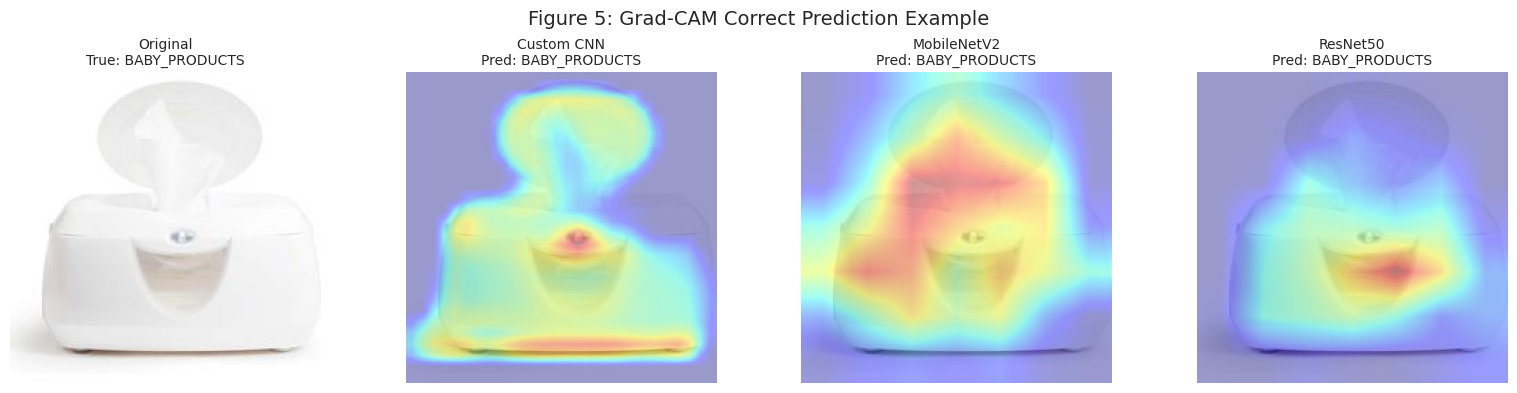

In [20]:
def plot_gradcam_comparison(row, title):
    img_array = load_image_array(row["path"])
    cols = 1 + len(models)
    fig, axes = plt.subplots(1, cols, figsize=(4 * cols, 4))

    axes[0].imshow(np.uint8(img_array))
    axes[0].axis("off")
    axes[0].set_title(f"Original\nTrue: {row['label']}", fontsize=10)

    for col_idx, (model_name, model) in enumerate(models.items(), start=1):
        pred_id = int(row[f"{model_name}_pred_id"])
        pred_label = row[f"{model_name}_pred_label"]
        heatmap = make_gradcam_heatmap(
            img_array,
            model,
            last_conv_layers[model_name],
            pred_index=pred_id,
        )
        overlay = overlay_heatmap(img_array, heatmap)
        axes[col_idx].imshow(overlay)
        axes[col_idx].axis("off")
        axes[col_idx].set_title(f"{model_name}\nPred: {pred_label}", fontsize=10)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    save_current_figure(title, fig=fig)
    plt.show()


correct_cols = [f"{model_name}_correct" for model_name in models]
all_correct = comparison_df[np.logical_and.reduce([comparison_df[col].values for col in correct_cols])]

if len(all_correct) > 0:
    selected_correct = all_correct.iloc[0]
    plot_gradcam_comparison(selected_correct, "Figure 5: Grad-CAM Correct Prediction Example")
else:
    print("No test image was correctly classified by all models. Showing first correct example per available model.")
    for model_name in models:
        model_correct = comparison_df[comparison_df[f"{model_name}_correct"]]
        if len(model_correct) > 0:
            plot_gradcam_comparison(model_correct.iloc[0], f"Grad-CAM Correct Example: {model_name}")
            break

## 14. Grad-CAM for Misclassified Images

Saved figure: /kaggle/working/nn_ecommerce_outputs/figures/figure_6_grad_cam_misclassification_example.png
Saved figure PDF: /kaggle/working/nn_ecommerce_outputs/figures/figure_6_grad_cam_misclassification_example.pdf


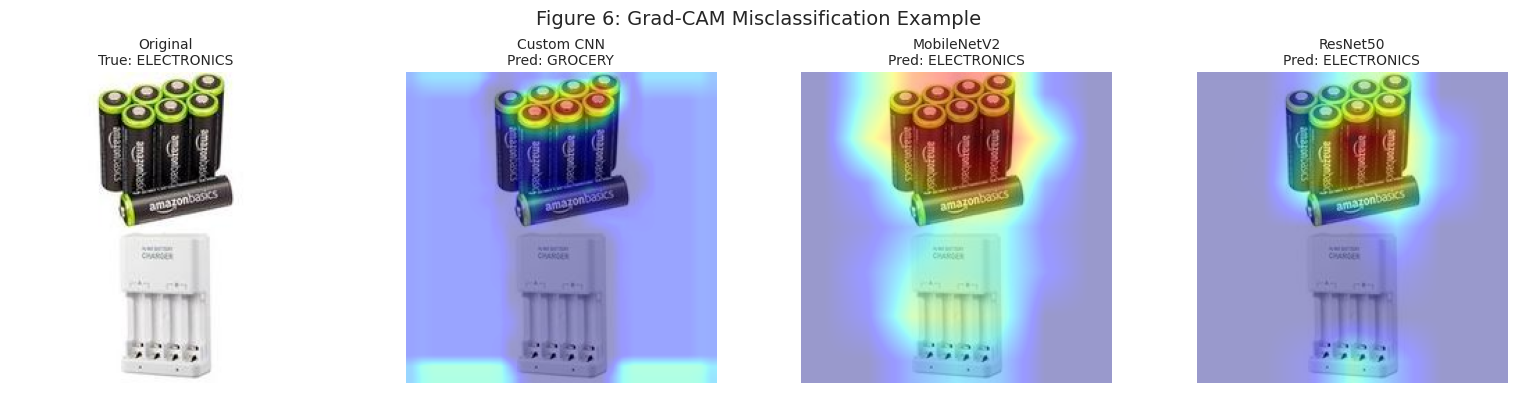

Misclassification details:
Custom CNN: true=ELECTRONICS | predicted=GROCERY | wrong
MobileNetV2: true=ELECTRONICS | predicted=ELECTRONICS | correct
ResNet50: true=ELECTRONICS | predicted=ELECTRONICS | correct


In [21]:
any_wrong = comparison_df[np.logical_or.reduce([~comparison_df[col].values for col in correct_cols])]

if len(any_wrong) > 0:
    selected_wrong = any_wrong.iloc[0]
    plot_gradcam_comparison(selected_wrong, "Figure 6: Grad-CAM Misclassification Example")
    print("Misclassification details:")
    for model_name in models:
        status = "correct" if selected_wrong[f"{model_name}_correct"] else "wrong"
        print(
            f"{model_name}: true={selected_wrong['label']} | "
            f"predicted={selected_wrong[f'{model_name}_pred_label']} | {status}"
        )
else:
    print("No misclassified test images were found. This is unusual but possible on an easy or tiny test set.")

## 15. SHAP Explanations for Selected Test Images

This uses SHAP image masking with a small number of evaluations for Kaggle stability. Increase `SHAP_MAX_EVALS` for richer explanations.

Figure 7: SHAP Explanation Examples
Running SHAP for Custom CNN on 1 image(s)
Saved figure: /kaggle/working/nn_ecommerce_outputs/figures/figure_7_shap_custom_cnn.png
Saved figure PDF: /kaggle/working/nn_ecommerce_outputs/figures/figure_7_shap_custom_cnn.pdf


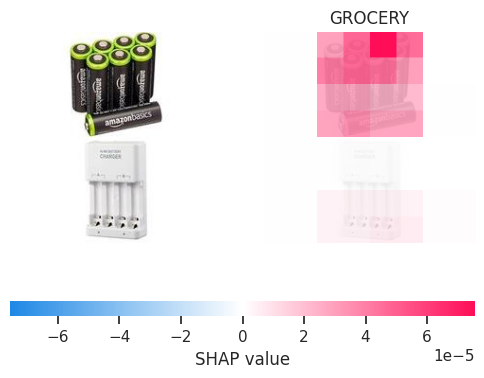

Running SHAP for MobileNetV2 on 1 image(s)
Saved figure: /kaggle/working/nn_ecommerce_outputs/figures/figure_7_shap_mobilenetv2.png
Saved figure PDF: /kaggle/working/nn_ecommerce_outputs/figures/figure_7_shap_mobilenetv2.pdf


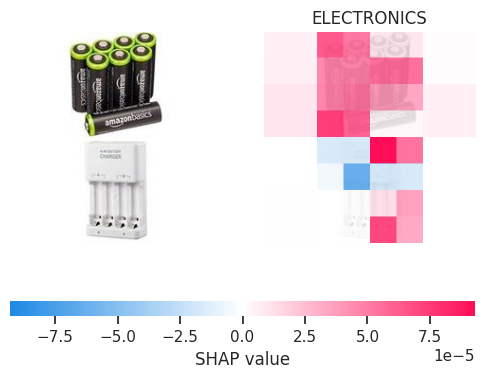

Running SHAP for ResNet50 on 1 image(s)


  0%|          | 0/298 [00:00<?, ?it/s]

Saved figure: /kaggle/working/nn_ecommerce_outputs/figures/figure_7_shap_resnet50.png
Saved figure PDF: /kaggle/working/nn_ecommerce_outputs/figures/figure_7_shap_resnet50.pdf


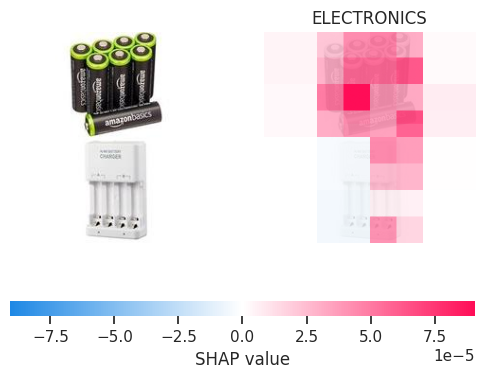

In [23]:
def ensure_shap():
    try:
        import shap
        return shap
    except Exception as first_exc:
        print("SHAP is not currently importable:", first_exc)
        print("Trying to install shap. If Kaggle internet is disabled, enable it or install shap manually.")
        try:
            import sys
            import subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap"])
            import shap
            return shap
        except Exception as second_exc:
            print("SHAP is unavailable in this runtime:", second_exc)
            return None


def sample_rows_for_shap():
    if len(any_wrong) > 0:
        rows = any_wrong.head(SHAP_IMAGES_PER_MODEL)
    else:
        rows = comparison_df.head(SHAP_IMAGES_PER_MODEL)
    return rows


def run_shap_for_model(model_name, rows):
    shap = ensure_shap()
    if shap is None:
        return None

    model = models[model_name]
    X = np.stack([load_image_array(path) for path in rows["path"]]).astype("float32")

    masker = shap.maskers.Image("blur(32,32)", X[0].shape)
    explainer = shap.Explainer(
        lambda batch: model.predict(batch, verbose=0),
        masker,
        output_names=class_names,
    )

    print(f"Running SHAP for {model_name} on {len(X)} image(s)")
    try:
        shap_values = explainer(
            X,
            max_evals=SHAP_MAX_EVALS,
            batch_size=max(1, BATCH_SIZE // 2),
            outputs=shap.Explanation.argsort.flip[:1],
        )
    except Exception as exc:
        print("Retrying SHAP without output slicing because this SHAP version rejected the slicing syntax.")
        print("Reason:", exc)
        shap_values = explainer(
            X,
            max_evals=SHAP_MAX_EVALS,
            batch_size=max(1, BATCH_SIZE // 2),
        )

    shap.image_plot(shap_values, X.astype("uint8"), show=False)
    save_current_figure(f"figure_7_shap_{model_name}", fig=plt.gcf())
    plt.show()
    return shap_values


shap_results = {}
if RUN_SHAP:
    shap_rows = sample_rows_for_shap()
    print("Figure 7: SHAP Explanation Examples")
    for model_name in models:
        shap_results[model_name] = run_shap_for_model(model_name, shap_rows)
else:
    print("RUN_SHAP is False. Set it to True in the configuration cell to generate SHAP explanations.")

## 16. Final Comparison Table

Edit the qualitative ratings after inspecting Grad-CAM and SHAP figures. The metric columns are filled automatically.

In [27]:
qualitative_ratings = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2", "ResNet50"],
    "Grad-CAM Quality": ["Review visually", "Review visually", "Review visually"],
    "SHAP Interpretability": ["Review visually", "Review visually", "Review visually"],
})

final_comparison = metrics_df.merge(
    qualitative_ratings,
    on="Model",
    how="left",
)

best_f1 = final_comparison["F1-score"].max()
fastest_time = final_comparison["Training time (sec)"].min()

def overall_finding(row):
    notes = []
    if np.isclose(row["F1-score"], best_f1):
        notes.append("best F1")
    if np.isclose(row["Training time (sec)"], fastest_time):
        notes.append("fastest training")
    if row["Model"] == "Custom CNN":
        notes.append("trained from scratch baseline")
    if not notes:
        notes.append("compare accuracy, cost, and explanations")
    return "; ".join(notes)

final_comparison["Overall Finding"] = final_comparison.apply(overall_finding, axis=1)
final_comparison = final_comparison[
    [
        "Model",
        "Accuracy",
        "F1-score",
        "Training time (min)",
        "Total parameters",
        "Grad-CAM Quality",
        "SHAP Interpretability",
        "Overall Finding",
    ]
]

save_table(final_comparison, "final_comparison_table")
display(final_comparison)

Saved table: /kaggle/working/nn_ecommerce_outputs/tables/final_comparison_table.csv


,Model,Accuracy,F1-score,Training time (min),Total parameters,Grad-CAM Quality,SHAP Interpretability,Overall Finding
0,Custom CNN,0.404107,0.336211,3.953837,457961,Review visually,Review visually,fastest training; trained from scratch baseline
1,MobileNetV2,0.717638,0.710696,4.063306,2269513,Review visually,Review visually,"compare accuracy, cost, and explanations"
2,ResNet50,0.771177,0.770033,6.646481,23606153,Review visually,Review visually,best F1


## 17. Research Question Answer Starters

Use the computed tables and figures above to write the final discussion.

In [30]:
rq_summary = f'''
### Research Question Summary

**RQ1. Custom CNN accuracy:** The custom CNN achieved {metrics_df.loc[metrics_df['Model'] == 'Custom CNN', 'Accuracy'].iloc[0]:.4f} accuracy and {metrics_df.loc[metrics_df['Model'] == 'Custom CNN', 'F1-score'].iloc[0]:.4f} weighted F1-score.

**RQ2. Transfer learning improvement:** Compare MobileNetV2 and ResNet50 against the custom CNN in the final table. A higher weighted F1-score indicates better classification performance.

**RQ3. Best performance-cost trade-off:** Use F1-score, training time, and parameter count together. The best model is not always the largest model.

**RQ4-RQ5. Grad-CAM attention:** Inspect Figures 5 and 6 to compare which image regions each model uses for correct and incorrect predictions.

**RQ6. SHAP evidence:** Inspect Figure 7 to identify positive and negative image regions influencing predictions.

**RQ7. Misclassification diagnosis:** Use the Grad-CAM misclassification figure and SHAP results to explain whether the model focused on the product, background, shape, color, logo, or misleading visual features.
'''
from IPython.display import Markdown, display
summary_path = OUTPUT_DIR / "research_question_summary.md"
summary_path.write_text(rq_summary, encoding="utf-8")
print(f"Saved research question summary: {summary_path}")
display(Markdown(rq_summary))

Saved research question summary: /kaggle/working/nn_ecommerce_outputs/research_question_summary.md



### Research Question Summary

**RQ1. Custom CNN accuracy:** The custom CNN achieved 0.4041 accuracy and 0.3362 weighted F1-score.

**RQ2. Transfer learning improvement:** Compare MobileNetV2 and ResNet50 against the custom CNN in the final table. A higher weighted F1-score indicates better classification performance.

**RQ3. Best performance-cost trade-off:** Use F1-score, training time, and parameter count together. The best model is not always the largest model.

**RQ4-RQ5. Grad-CAM attention:** Inspect Figures 5 and 6 to compare which image regions each model uses for correct and incorrect predictions.

**RQ6. SHAP evidence:** Inspect Figure 7 to identify positive and negative image regions influencing predictions.

**RQ7. Misclassification diagnosis:** Use the Grad-CAM misclassification figure and SHAP results to explain whether the model focused on the product, background, shape, color, logo, or misleading visual features.


## 18. Saved Outputs

In [31]:
def build_combined_pdf_report():
    if not SAVED_FIGURES:
        print("No saved figures were found for the combined PDF report.")
        return None

    report_path = OUTPUT_DIR / "ecommerce_nn_explainability_report.pdf"
    with PdfPages(report_path) as pdf:
        for figure_info in SAVED_FIGURES:
            png_path = Path(figure_info["png"])
            if not png_path.exists():
                continue
            image = Image.open(png_path)
            fig = plt.figure(figsize=(11, 8.5))
            plt.imshow(image)
            plt.axis("off")
            plt.title(str(figure_info["name"]).replace("_", " ").title(), fontsize=12)
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print(f"Saved combined PDF report: {report_path}")
    return report_path


combined_report_path = build_combined_pdf_report()

print("\nSaved files:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print("-", path)

Saved combined PDF report: /kaggle/working/nn_ecommerce_outputs/ecommerce_nn_explainability_report.pdf

Saved files:
- /kaggle/working/nn_ecommerce_outputs/ecommerce_nn_explainability_report.pdf
- /kaggle/working/nn_ecommerce_outputs/figures/figure_1_dataset_samples.pdf
- /kaggle/working/nn_ecommerce_outputs/figures/figure_1_dataset_samples.png
- /kaggle/working/nn_ecommerce_outputs/figures/figure_1a_class_distribution.pdf
- /kaggle/working/nn_ecommerce_outputs/figures/figure_1a_class_distribution.png
- /kaggle/working/nn_ecommerce_outputs/figures/figure_2_model_design_workflow.pdf
- /kaggle/working/nn_ecommerce_outputs/figures/figure_2_model_design_workflow.png
- /kaggle/working/nn_ecommerce_outputs/figures/figure_3_accuracy_and_loss_curves.pdf
- /kaggle/working/nn_ecommerce_outputs/figures/figure_3_accuracy_and_loss_curves.png
- /kaggle/working/nn_ecommerce_outputs/figures/figure_4_confusion_matrix_custom_cnn_normalized.pdf
- /kaggle/working/nn_ecommerce_outputs/figures/figure_4_conf

In [ ]:
!zip -r all_results.zip /kaggle/working